In [74]:
import os
import cv2
import torch
import pyttsx3
from datetime import datetime
import numpy as np
import requests
from IPython.display import display, Audio
import openai
import time
from PIL import Image
import sys
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt

# Load YOLOv7
sys.path.insert(0, './yolov7')
from models.experimental import attempt_load  # Import the function to load the model
from utils.general import non_max_suppression  # Import the utility function
model = attempt_load('../models/best.pt', map_location=torch.device('cpu'))
model.eval()  # Set the model to evaluation mode

# Load GPT API
gpt_api = os.environ["OPENAI_API_KEY"]  # set this in your shell/.env, do not hardcode

# Assembly data
file_path = 'steps_components_tools.xlsx'
steps_df = pd.read_excel(file_path, sheet_name='Steps')
components_tools_df = pd.read_excel(file_path, sheet_name='Components_Tools')

Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
IDetect.fuse


## Function 1 photo capture

In [83]:
import os
# 转换颜色格式以便Matplotlib显示
def show_image(frame):
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    plt.axis('off')
    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    plt.title(f'Image_{timestamp}')
    plt.show()

In [84]:
import os
def preprocess_image(frame):
    # 将图像转换为 RGB 格式并调整大小
    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    # img = cv2.resize(img, (1280, 960))
    img = img / 255.0  # 归一化图像
    img = np.transpose(img, (2, 0, 1))  # 将数据布局从 HWC 更改为 CHW
    img = np.expand_dims(img, 0)  # 添加批次维度
    img = torch.from_numpy(img).float()  # 将 numpy.ndarray 转换为 torch.Tensor
    return img

In [85]:
import os
def capture_image():
    cap = cv2.VideoCapture(0)  # 默认摄像头
    ret, frame = cap.read()
    cap.release()
    if ret:
        show_image(frame)
        img = preprocess_image(frame)
        return img
    else:
        return None

## Function 2 Yolov7 object detection with bounding boxes and labels

In [86]:
import os
def detect_items(image, item_type='components'):
    # 将图像转换为 NumPy 数组并去除批次维度
    frame = image.squeeze().numpy().transpose(1, 2, 0) * 255
    frame = frame.astype(np.uint8)
    
    # 运行推理
    with torch.no_grad():
        predictions = model(image)
        show_image(predictions)

        if isinstance(predictions, tuple):
            predictions = predictions[0]

        predictions = non_max_suppression(predictions)

    # 提取预测结果
    detected_items = []
    for detection in predictions[0]:
        x1, y1, x2, y2, conf, cls = detection[:6]  # 提取前 6 个元素
        if conf > 0.5:  # 设置置信度阈值
            label = model.names[int(cls)]
            if (item_type == 'components' and any(label == item['name'] for item in component_and_tool_classes)) or (item_type == 'steps' and label in step_classes):
                detected_items.append(label)
                # Draw bounding box
                color = (0, 255, 0) if item_type == 'components' else (255, 0, 0)
                cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)
                # Put label
                cv2.putText(frame, label, (int(x1), int(y1) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
    
    # 保存并显示标注的图像
    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    annotated_image_path = f'annotated_{item_type}_{timestamp}.jpg'
    cv2.imwrite(annotated_image_path, frame)
    display(Image.open(annotated_image_path))
    
    return detected_items


## Function 3 validation

In [87]:
import os
def validate_items(detected, step_details, validation_type='components'):
    if validation_type == 'components':
        required = [comp['name'] for comp in step_details['components']] + ([step_details['tool']['name']] if step_details['tool'] else [])
        if all(item in detected for item in required):
            return True, "All components and tools are correct."
        missing = [item for item in required if item not in detected]
        return False, f"Missing components or tools: {missing}"
    else:
        expected = step_details['order']
        return expected in detected, "Operation correct." if expected in detected else "Operation incorrect."

## Function 4 Reading and using error template

In [88]:
import os
# 从Excel文件读取数据
file_path = 'error_templates.xlsx'
error_templates_df = pd.read_excel(file_path)

# 将模板转换为字典
error_templates = dict(zip(error_templates_df['error_type'], error_templates_df['template']))

# 定义 handle_error 函数
def handle_error(error_type, details, operator_name, location):
    # 提供默认值
    details.setdefault('error', 'Unknown error')
    details.setdefault('step', 'Unknown step')
    details.setdefault('task', 'Unknown task')
    details.setdefault('expected', 'Unknown expected')
    details.setdefault('actual', 'Unknown actual')
    
    now = datetime.now().strftime("%Y-%m-%d %H:%M")
    
    template = error_templates.get(error_type, None)
    if not template:
        return "Unknown error type"

    # 格式化模板，使用 **details 解包字典内容
    error_log = template.format(now=now, operator_name=operator_name, location=location, **details)
    return error_log

## Function 5 GPT API achievement

In [89]:
import os
def gpt(step_details, error_description, api_key):
    prompt = f"Error Description: {error_description}\nStep Details: {step_details}\nPlease generate a detailed corrective instruction."
    openai.api_key = api_key
    response = openai.ChatCompletion.create(
        model="gpt-4",
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt}
        ],
        max_tokens=150
    )
    return response['choices'][0]['message']['content'].strip()

## Function 6 Text to Speech

In [90]:
import os
def text_to_speech(text, file_name):
    try:
        engine = pyttsx3.init()# 初始化TTS引擎

        rate = engine.getProperty('rate')  # 获取当前语速
        engine.setProperty('rate', rate - 80)  # 减慢语速
        volume = engine.getProperty('volume')  # 获取当前音量
        engine.setProperty('volume', volume + 0.25)  # 增加音量
        voices = engine.getProperty('voices')  # 获取所有可用的声音
        engine.setProperty('voice', voices[1].id)  # 更改语音（0为男性，1为女性）
        
        engine.say(text) # 将文本转换为语音
        engine.save_to_file(text, file_name) # 保存为音频文件
        engine.runAndWait() # 运行并等待完成
    except Exception as e:
        print(f"Error with text-to-speech: {e}")
        print(text) # 如果TTS转换失败，打印文本作为替代

## Main function

In [91]:
import os
def main():
    operator_name = input("Please enter the operator's name: ")
    location = "Assembly Line 3, Workstation 7"

    for step in steps:
        print(f"Processing {step['order']}")
        
        component_names = ', '.join([comp['name'] for comp in step['components']])
        tool_name = step['tool']['name'] if step['tool'] else 'none'
        timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
        file_name = f"{tool_name}_{timestamp}.mp4"
        text_to_speech(f"Please prepare the following components: {component_names} and tools: {tool_name}",file_name)
        time.sleep(3)

        image = capture_image()
        detected_components = detect_items(image, item_type='components')
        comp_valid, comp_message = validate_items(detected_components, step, validation_type='components')
        if not comp_valid:
            error_log = {
                'step': step['order'],
                'task': step['instructions'],
                'expected': component_names,
                'actual': ', '.join(detected_components),
            }
            print(handle_error('Component', error_log, operator_name, location))

            gpt_output = gpt(step, error_log, gpt_api)
            timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
            file_name = f"gpt_{timestamp}.mp4"
            text_to_speech(gpt_output,file_name)  # Function6
        else:
            timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
            file_name = f"instructions_{timestamp}.mp4"
            text_to_speech(f"Please follow the instructions to complete the step: {step['instructions']}",'InstrucSentence'+step+'.mp4')
            time.sleep(step['time'])

            image = capture_image()
            detected_steps = detect_items(image, item_type='steps')
            step_valid, step_message = validate_items(detected_steps, step, validation_type='steps')

            if not step_valid:
                error_log = handle_error('Operation', {
                    'step': step['order'],
                    'task': step['instructions'],
                    'error': 'Operation not performed correctly'
                }, operator_name, location)
                gpt_output = gpt(step, error_log, gpt_api)
                
                timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
                file_name = f"errorinstructions_{timestamp}.mp4"
                text_to_speech(gpt_output, file_name)
            else:
                timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
                file_name = f"errorinstructions_{timestamp}.mp4"
                text_to_speech("Operation correct. Proceed to the next step.", file_name)

Please enter the operator's name: yuchen
Processing S6


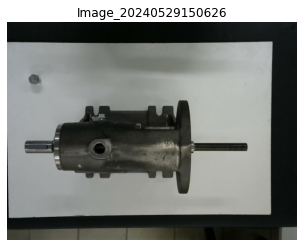

error: OpenCV(4.8.1) :-1: error: (-5:Bad argument) in function 'cvtColor'
> Overload resolution failed:
>  - src is not a numerical tuple
>  - Expected Ptr<cv::UMat> for argument 'src'


In [92]:
import os
if __name__ == '__main__':
    main()

In [ ]:
import os
